In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, cdist

from pathlib import Path

In [35]:

plt.rcParams.update({
    # Use LaTeX for text rendering
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Font sizes (match your LaTeX doc's font size)
    "font.size": 20*2,
    "axes.titlesize": 16*2,
    "axes.labelsize": 22*2,
    "xtick.labelsize": 20*2,
    "ytick.labelsize": 20*2,
    "legend.fontsize": 15*2,

    # Figure size — match LaTeX text width
    # For A4 with default margins: ~6.3in wide
    "figure.figsize": (5.9, 5.9),  # golden ratio height

    # Line/marker quality
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

# Notebook to compare 10 and 4 bar tracks

In [3]:

def load_h5_files(folder, key, slices = None):
    files = list(Path(folder).glob("*.h5"))[:slices]
    return pd.concat([pd.read_hdf(f, key) for f in files], ignore_index = True)

In [4]:
path_5bar = '/gluster/data/next/files/NEXUS_John/0vbb/4bar'
path_13bar = '/gluster/data/next/files/NEXUS_John/0vbb/10bar'

hits_5bar  = load_h5_files(path_5bar, 'MC/hits', 1)
pinfo_5bar = load_h5_files(path_5bar, 'MC/particles', 1)
display(hits_5bar)
display(pinfo_5bar)

,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
7838565,4999,123.592705,10.686277,435.896667,2.619385,0.000098,ACTIVE,1,758
7838566,4999,123.596489,10.687006,435.890991,2.619583,0.001618,ACTIVE,1,759
7838567,4999,123.596260,10.688207,435.891846,2.619642,0.000015,ACTIVE,1,760
7838568,4999,123.595810,10.690542,435.893463,2.619757,0.001285,ACTIVE,1,761


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222654,4999,43607,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.839783,...,-0.015963,-0.013234,-0.007333,-0.0,-0.0,-0.0,0.000473,0.003339,phot,NoProcess
222655,4999,43606,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.870083,...,-0.057298,0.072363,0.060479,0.0,-0.0,0.0,0.011779,0.487257,phot,NoProcess
222656,4999,54751,e-,0,1,124.659485,14.253165,453.109955,2.148500,124.667755,...,0.047024,0.020670,-0.100803,-0.0,-0.0,0.0,0.012374,0.115835,eIoni,NoProcess
222657,4999,60499,e-,0,1,119.512756,6.900838,439.812958,2.485482,119.516144,...,-0.042584,0.118401,0.037350,0.0,-0.0,-0.0,0.016587,0.696750,eIoni,NoProcess


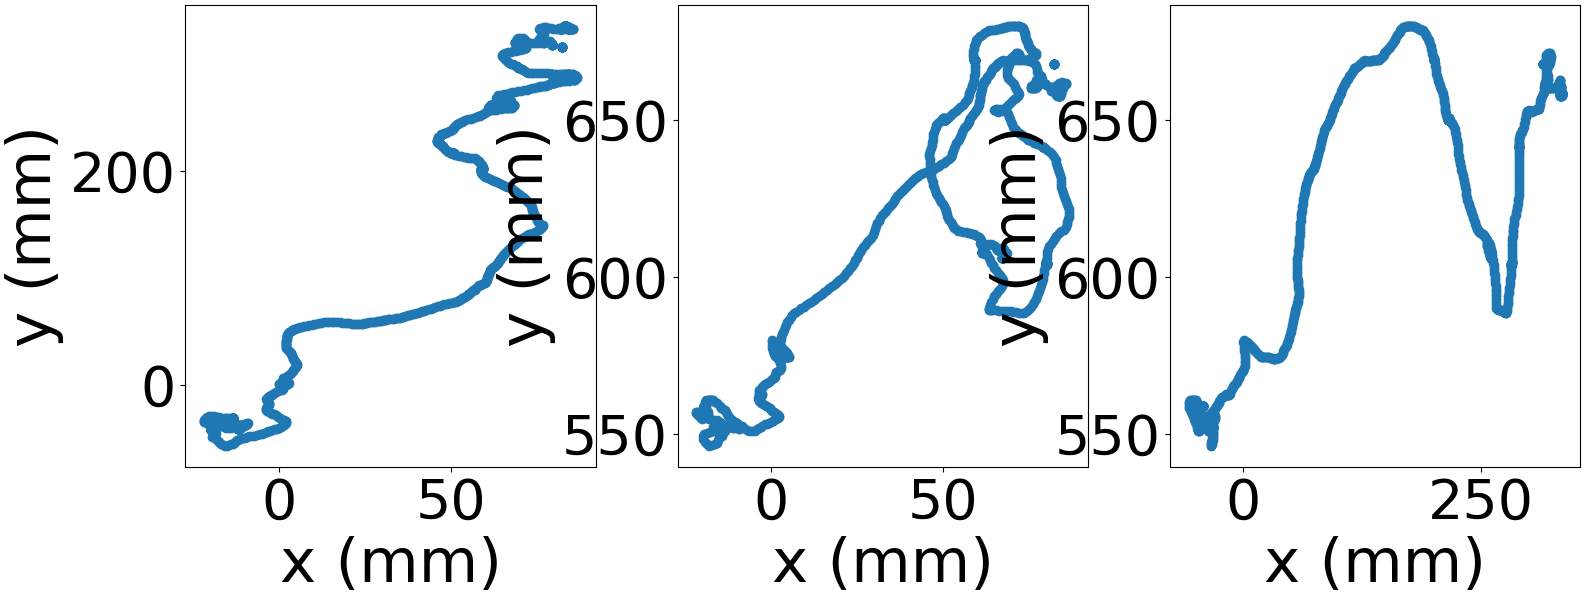

Space between hits:
-0.008179605 -0.028589904 -0.018435512
-0.008179605 -0.028589904 -0.018435512


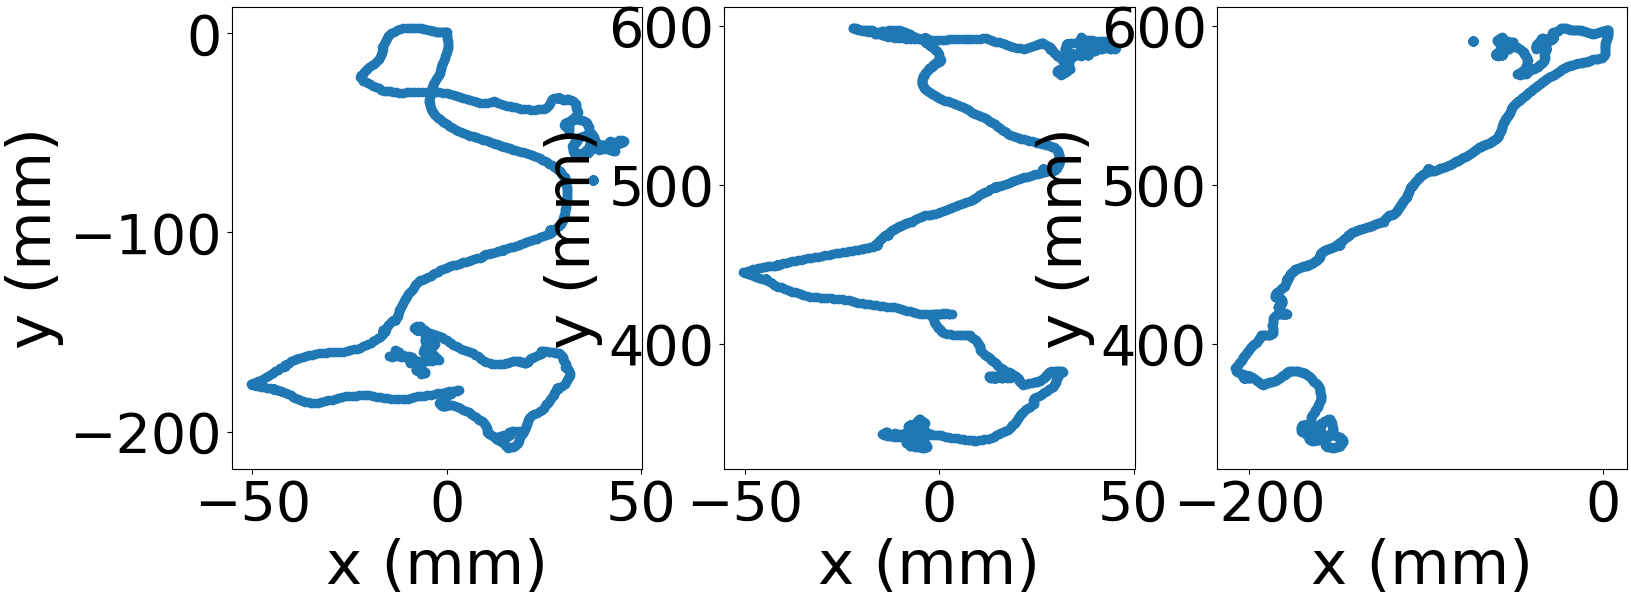

Space between hits:
-0.0043046586 -0.10361399 -0.14369641
-0.0043046586 -0.10361399 -0.14369641
1


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,0,51017,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.805077,...,-0.008368,-0.007301,-0.005531,-0.0,-0.0,-0.0,0.000151,0.000089,phot,NoProcess
65,0,51016,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.805832,...,0.005313,0.040481,0.038972,0.0,0.0,-0.0,0.003108,0.029784,phot,NoProcess
66,0,51015,e-,0,50974,-19.805016,-42.237877,558.907837,0.406865,-19.664625,...,0.092126,0.054987,-0.007555,0.0,0.0,-0.0,0.011196,0.387831,phot,NoProcess
67,0,53581,e-,0,1,-13.370129,-31.888691,551.881958,0.522213,-13.391294,...,0.150568,0.004748,-0.025702,-0.0,0.0,-0.0,0.022362,1.291175,eIoni,NoProcess


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
69,1,3916,e-,0,2,-3.864816,-29.413263,591.506104,0.273158,-3.598248,...,0.033836,0.146046,0.120614,-0.0,-0.0,-0.0,0.035025,2.393882,eIoni,NoProcess
70,1,7705,e-,0,2,28.559145,-32.435555,585.617676,0.441592,28.888206,...,-0.071426,0.099203,-0.059719,0.0,0.0,0.0,0.017801,0.728963,eIoni,NoProcess
71,1,12071,e-,0,2,34.305172,-60.401295,581.797058,0.734256,34.251755,...,-0.037181,-0.116086,-0.021722,0.0,-0.0,0.0,0.014786,0.513130,eIoni,NoProcess
72,1,13293,e-,0,2,33.030727,-54.763699,588.663635,0.778293,32.981773,...,-0.119052,0.051345,0.013397,-0.0,-0.0,-0.0,0.016362,0.638501,eIoni,NoProcess
73,1,15039,gamma,0,2,35.959293,-60.028492,590.301514,0.862421,37.647312,...,0.002402,-0.019521,0.000401,0.0,-0.0,0.0,0.019673,13.823136,eBrem,phot
74,1,15083,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647301,...,-0.000889,-0.006112,-0.002953,0.0,0.0,-0.0,0.000046,0.000098,phot,NoProcess
75,1,15082,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647308,...,-0.002713,0.000705,0.006132,-0.0,0.0,0.0,0.000044,0.000013,phot,NoProcess
76,1,15081,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647282,...,-0.003235,-0.002717,-0.001779,-0.0,-0.0,0.0,0.000021,0.000045,phot,NoProcess
77,1,15080,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647472,...,0.004363,0.002150,0.007125,-0.0,-0.0,0.0,0.000073,0.000667,phot,NoProcess
78,1,15079,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647182,...,-0.004483,-0.012144,-0.002943,-0.0,-0.0,-0.0,0.000172,0.001154,phot,NoProcess


1


In [81]:
# Lets look at them quickly, extract some info
for evt, df in hits_5bar.groupby('event_id'):
    fig, axes = plt.subplots(1,3, figsize=(18,6))
    axes[0].scatter(df.x, df.y)
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    
    axes[1].scatter(df.x, df.z)
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    
    axes[2].scatter(df.y, df.z)
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    plt.show()
    
    print('Space between hits:')
    print(np.average(np.diff(df.x.values)), np.average(np.diff(df.y.values)), np.average(np.diff(df.z.values)))
    print(np.average(np.diff(df.x.values)), np.average(np.diff(df.y.values)), np.average(np.diff(df.z.values)))
    if evt > 0:
        print(evt)
        break

    
    
for evt, df_p in pinfo_5bar.groupby('event_id'):
    display(df_p)
    if evt > 0:
        print(evt)
        break

In [82]:
def tag_hits_in_event(event_hits   : pd.DataFrame
                     , *
                     , min_samples : int
                     , scale_xy    : float
                     , scale_z     : float
                     ) -> pd.DataFrame:
    """
    Applies DBSCAN clustering to a DataFrame containing hits from a single event.
    Hits coordinates are scaled to account for the anisotropy of the detector geometry.
    A 'cluster' column is added to the group with the resulting labels.

    Parameters
    ----------
    event_hits  : pd.DataFrame
        DataFrame with hits from a single event. Must contain 'X', 'Y', 'Z' columns.
    min_samples : int
        Minimum number of samples required to form a dense region (cluster).
        This includes the point itself.
    scale_xy    : float
        Scaling factor to apply to the XY coordinates before clustering.
    scale_z     : float
        Scaling factor to apply to the Z coordinate before clustering.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with a 'cluster' column added.
    """
    coords = event_hits[['x', 'y', 'z']].to_numpy()
    # A proper scaling leads to hits being separeted 
    # by a distance of 1 in the DBSCAN metric space
    coords[:, :2] /= scale_xy
    coords[:, 2]  /= scale_z

    # eps parameter is fixed to a value a bit higher of √3
    # to retain diagonal neighbours in the same cluster
    labels = DBSCAN(eps=1.8, min_samples=min_samples).fit_predict(coords)
    event_hits['cluster'] = labels

    return event_hits

def cluster_tagger(df_hits      : pd.DataFrame
                  , *
                  , min_samples : int
                  , scale_xy    : float
                  , scale_z     : float
                  ) -> pd.DataFrame:
    """
    This function groups the input DataFrame by 'event' and applies the
    `tag_hits_in_event` function to each event's group of hits.

    Parameters
    ----------
    df_hits : pd.DataFrame
        DataFrame with hit information. Must contain 'X', 'Y', 'Z', and 'event'.
    min_samples, scale_xy, scale_z : 
        See `tag_hits_in_event`
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'cluster' column indicating the
        cluster label for each hit (-1 for noise).
    """
    if df_hits.empty:
        return df_hits.assign(cluster=pd.Series(dtype=int))

    df_clustered = df_hits.groupby('event_id', as_index=False, group_keys=False) \
                          .apply( tag_hits_in_event
                                , min_samples = min_samples
                                , scale_xy    = scale_xy
                                , scale_z     = scale_z )
    
    return df_clustered.set_index(df_hits.index)
    

## clusterise

In [83]:
tagged_hits_5bar = cluster_tagger(hits_5bar, min_samples = 5, scale_xy = 2, scale_z = 2)

Event: 1, Cluster: 0


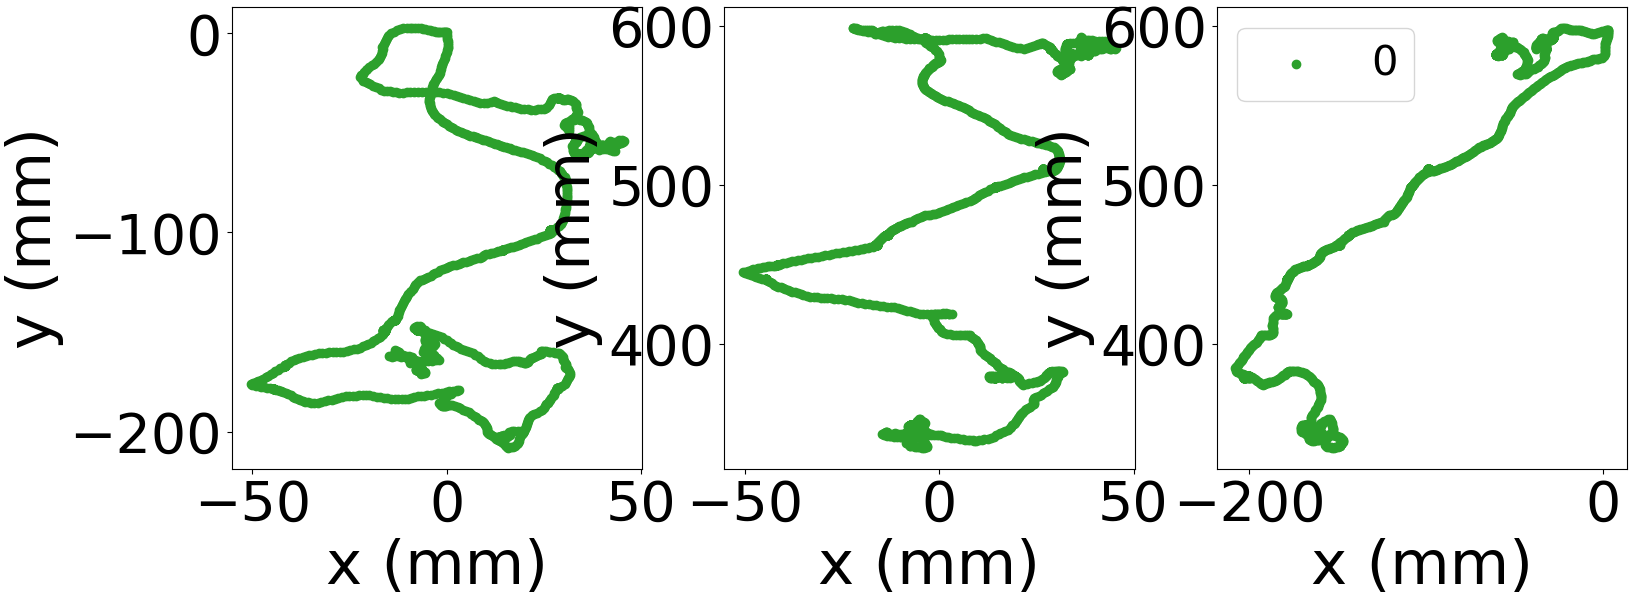

In [84]:
first_event = 0

colors = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig, axes = plt.subplots(1,3, figsize=(18,6))
for (event, cluster), df in tagged_hits_5bar.groupby(['event_id', 'cluster']):
    
    colours = next(colors)
    first_event += 1
    if first_event == 3:
        if cluster == -1:
            continue
        print(f'Event: {event}, Cluster: {cluster}')
        #print(df)
    
    
        axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
        axes[0].set_xlabel('x (mm)')
        axes[0].set_ylabel('y (mm)')
        
        axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
        axes[1].set_xlabel('x (mm)')
        axes[1].set_ylabel('y (mm)')
    
        axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
        axes[2].set_xlabel('x (mm)')
        axes[2].set_ylabel('y (mm)')
        
        axes[2].legend()
    
        plt.show()
        break
    



In [85]:
step = np.sqrt(df['x'].diff()**2 + df['y'].diff()**2 + df['z'].diff()**2)
print(step)

1477         NaN
1478    0.984617
1479    0.999899
1480    0.998771
1481    0.998951
          ...   
3109    0.008387
3110    0.020081
3111    0.003505
3112    0.008418
3113    0.002210
Length: 1588, dtype: float32


## take the biggest cluster, find the maximal distance between the points to collect length

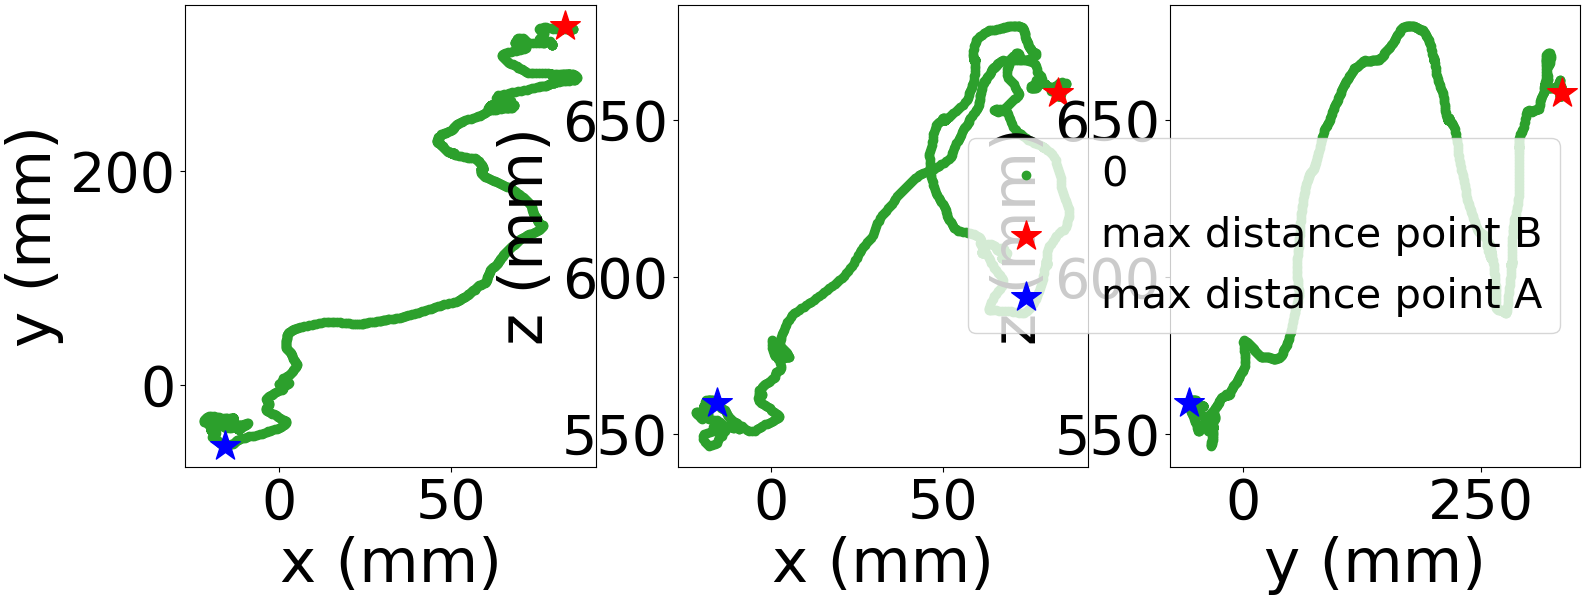

evt 0 max distance 416.6268695322322mm
maximal positions: x     83.345116
y    335.279694
z    658.526917
Name: 1107, dtype: float32, x    -15.783838
y    -57.103268
z    559.597595
Name: 1239, dtype: float32


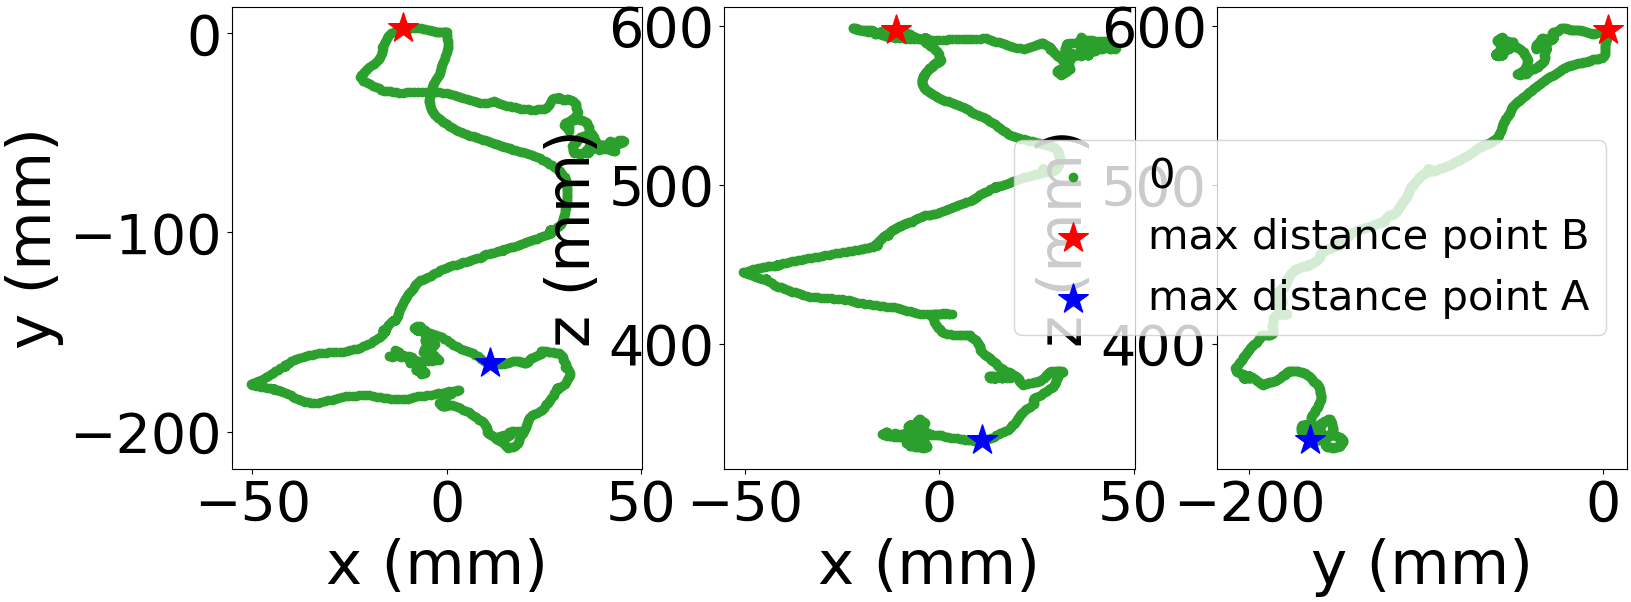

evt 1 max distance 308.8667780429868mm
maximal positions: x    -11.191232
y      2.336496
z    597.528809
Name: 1498, dtype: float32, x     10.988322
y   -165.711105
z    339.329742
Name: 2826, dtype: float32


In [87]:
for evt, df in tagged_hits_5bar.groupby('event_id'):
    # check if event has one track larger than 100. If so, include
    if (df.cluster.value_counts() > 100).sum() == 1:
        dominant_cluster = df['cluster'].value_counts()[df['cluster'].value_counts() > 100].index[0]
        df = df[df['cluster'] == dominant_cluster]
        
        coords = df[['x', 'y', 'z']].to_numpy()
        dists  = cdist(coords, coords)
        idx    = np.unravel_index(dists.argmax(), dists.shape)

        max_dist = dists[idx]
        pos_a    = df[['x', 'y', 'z']].iloc[idx[0]]
        pos_b    = df[['x', 'y', 'z']].iloc[idx[1]]
        
        
        fig, axes = plt.subplots(1,3, figsize=(18,6))
        axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
        axes[0].set_xlabel('x (mm)')
        axes[0].set_ylabel('y (mm)')
    
        axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
        axes[1].set_xlabel('x (mm)')
        axes[1].set_ylabel('z (mm)')
    
        axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
        axes[2].set_xlabel('y (mm)')
        axes[2].set_ylabel('z (mm)')
    
        
        
        axes[0].scatter(pos_a.x, pos_a.y, marker='*', color='red', s=500)
        axes[1].scatter(pos_a.x, pos_a.z, marker='*', color='red', s=500)
        axes[2].scatter(pos_a.y, pos_a.z, marker='*', color='red', s=500, label = 'max distance point B')
        
        axes[0].scatter(pos_b.x, pos_b.y, marker='*', color='blue', s=500)
        axes[1].scatter(pos_b.x, pos_b.z, marker='*', color='blue', s=500)
        axes[2].scatter(pos_b.y, pos_b.z, marker='*', color='blue', s=500, label = 'max distance point A')
        
        axes[2].legend()
        plt.show()
        print(f'evt {evt} max distance {max_dist}mm')
        print(f'maximal positions: {pos_a}, {pos_b}')
    if evt > 0:
        break

,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
1477,1,0.010303,0.342386,580.935547,0.003620,0.001505,ACTIVE,2,0,0
1478,1,-0.112376,0.595204,581.879211,0.007198,0.001088,ACTIVE,2,1,0
1479,1,-0.340987,0.626809,582.852112,0.010832,0.002784,ACTIVE,2,2,0
1480,1,-0.636849,0.715324,583.801941,0.014464,0.001074,ACTIVE,2,3,0
1481,1,-0.992695,0.710783,584.735352,0.018097,0.001033,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
3109,1,-7.039067,-169.158890,345.875854,2.400260,0.000257,ACTIVE,1,682,0
3110,1,-7.035063,-169.165176,345.857208,2.400737,0.002257,ACTIVE,1,683,0
3111,1,-7.032881,-169.166428,345.854767,2.400841,0.000292,ACTIVE,1,684,0
3112,1,-7.034186,-169.170532,345.847534,2.401103,0.001924,ACTIVE,1,685,0


1


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
82,1,2,e-,1,0,0.0,0.0,580.0,0.0,38.249809,...,-0.138806,0.403599,1.103954,-0.0,-0.0,0.0,0.778184,264.542542,none,NoProcess
106,1,1,e-,1,0,0.0,0.0,580.0,0.0,-7.032128,...,0.086939,-1.996969,-0.736452,0.0,0.0,0.0,1.679646,637.441345,none,NoProcess


901.9839

[    2  3916  7705 12071 13293     1 27243 27258 27257 27256 27255 27254
 27253 27252 27278 27277 27276 27251 28352 32165 33380 36187 37657 44431
 44741 49127 54678 60730 62441]


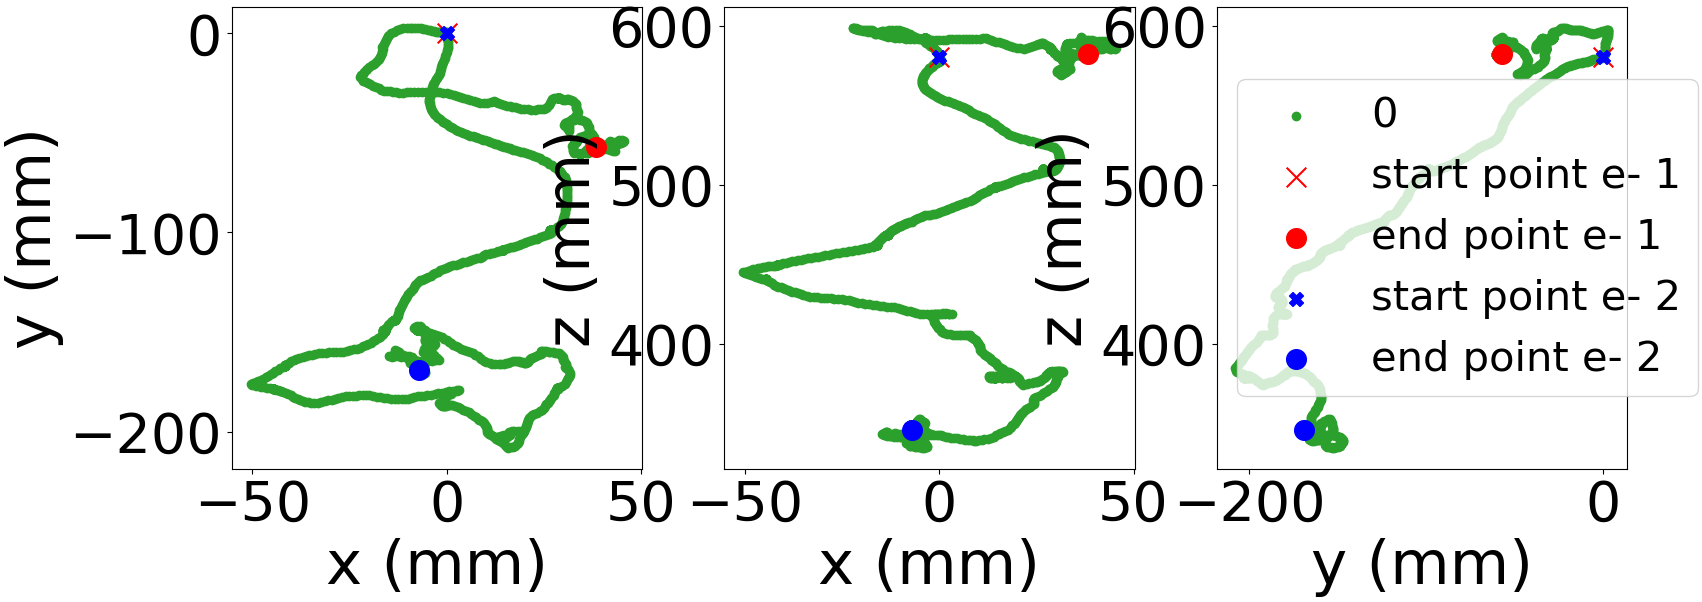

In [88]:
## and length via true particle information

display(df)
print(df.event_id.unique()[0])
mask = (pinfo_5bar.event_id == df.event_id.unique()[0]) & (pinfo_5bar.creator_proc == 'none')
nubb0_pid = pinfo_5bar[mask]

display(nubb0_pid)
display(nubb0_pid.length.sum())
print(df.particle_id.unique())


fig, axes = plt.subplots(1,3, figsize=(18,6))
axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')

axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('z (mm)')

axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
axes[2].set_xlabel('y (mm)')
axes[2].set_ylabel('z (mm)')



axes[0].scatter(nubb0_pid.iloc[0].initial_x, nubb0_pid.iloc[0].initial_y, marker='x', color='red', s=200)
axes[1].scatter(nubb0_pid.iloc[0].initial_x, nubb0_pid.iloc[0].initial_z, marker='x', color='red', s=200)
axes[2].scatter(nubb0_pid.iloc[0].initial_y, nubb0_pid.iloc[0].initial_z, marker='x', color='red', s=200, label = 'start point e- 1')

axes[0].scatter(nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, marker='o', color='red', s=200)
axes[1].scatter(nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_z, marker='o', color='red', s=200)
axes[2].scatter(nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z, marker='o', color='red', s=200, label = 'end point e- 1')


axes[0].scatter(nubb0_pid.iloc[1].initial_x, nubb0_pid.iloc[1].initial_y, marker='X', color='blue', s=100)
axes[1].scatter(nubb0_pid.iloc[1].initial_x, nubb0_pid.iloc[1].initial_z, marker='X', color='blue', s=100)
axes[2].scatter(nubb0_pid.iloc[1].initial_y, nubb0_pid.iloc[1].initial_z, marker='X', color='blue', s=100, label = 'start point e- 2')

axes[0].scatter(nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, marker='o', color='blue', s=200)
axes[1].scatter(nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_z, marker='o', color='blue', s=200)
axes[2].scatter(nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z, marker='o', color='blue', s=200, label = 'end point e- 2')


axes[2].legend()
plt.show()


,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
1477,1,0.010303,0.342386,580.935547,0.003620,0.001505,ACTIVE,2,0,0
1478,1,-0.112376,0.595204,581.879211,0.007198,0.001088,ACTIVE,2,1,0
1479,1,-0.340987,0.626809,582.852112,0.010832,0.002784,ACTIVE,2,2,0
1480,1,-0.636849,0.715324,583.801941,0.014464,0.001074,ACTIVE,2,3,0
1481,1,-0.992695,0.710783,584.735352,0.018097,0.001033,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
3109,1,-7.039067,-169.158890,345.875854,2.400260,0.000257,ACTIVE,1,682,0
3110,1,-7.035063,-169.165176,345.857208,2.400737,0.002257,ACTIVE,1,683,0
3111,1,-7.032881,-169.166428,345.854767,2.400841,0.000292,ACTIVE,1,684,0
3112,1,-7.034186,-169.170532,345.847534,2.401103,0.001924,ACTIVE,1,685,0


/tmp/ipykernel_1499239/2579134228.py:70: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


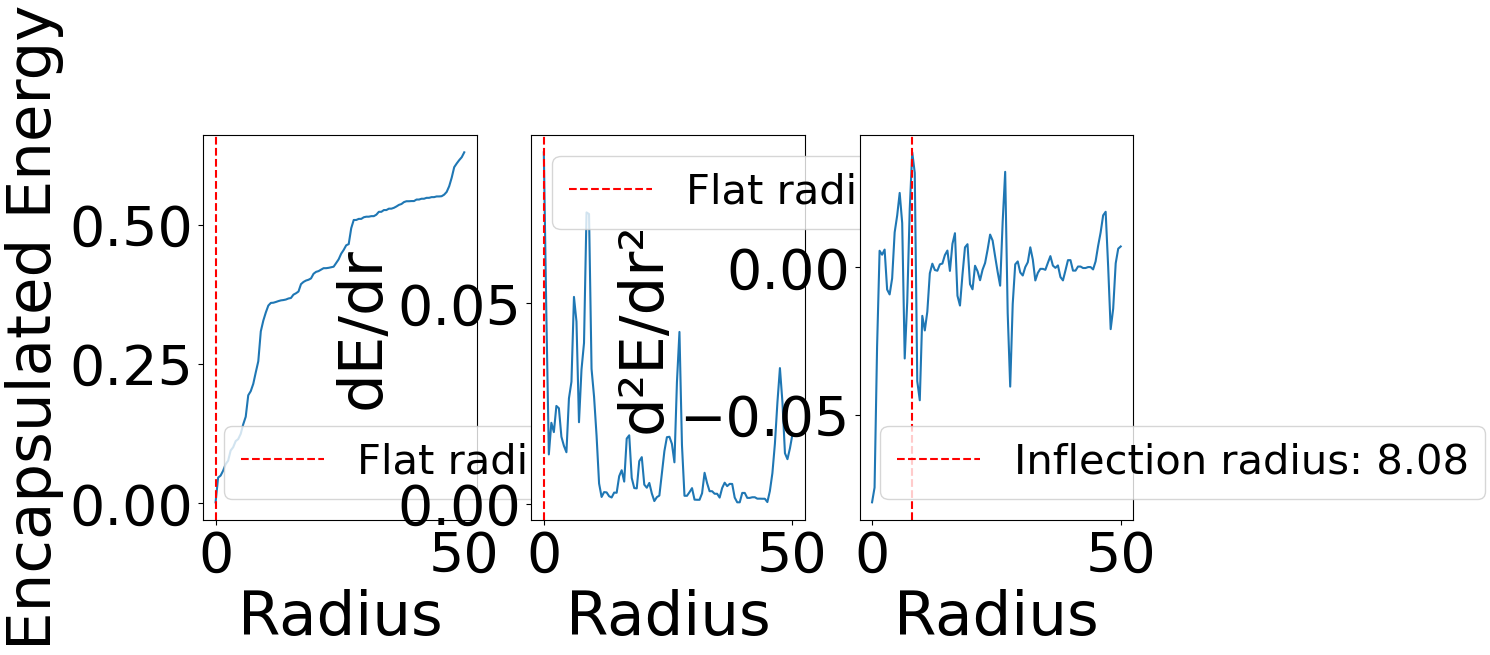

/tmp/ipykernel_1499239/2579134228.py:94: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


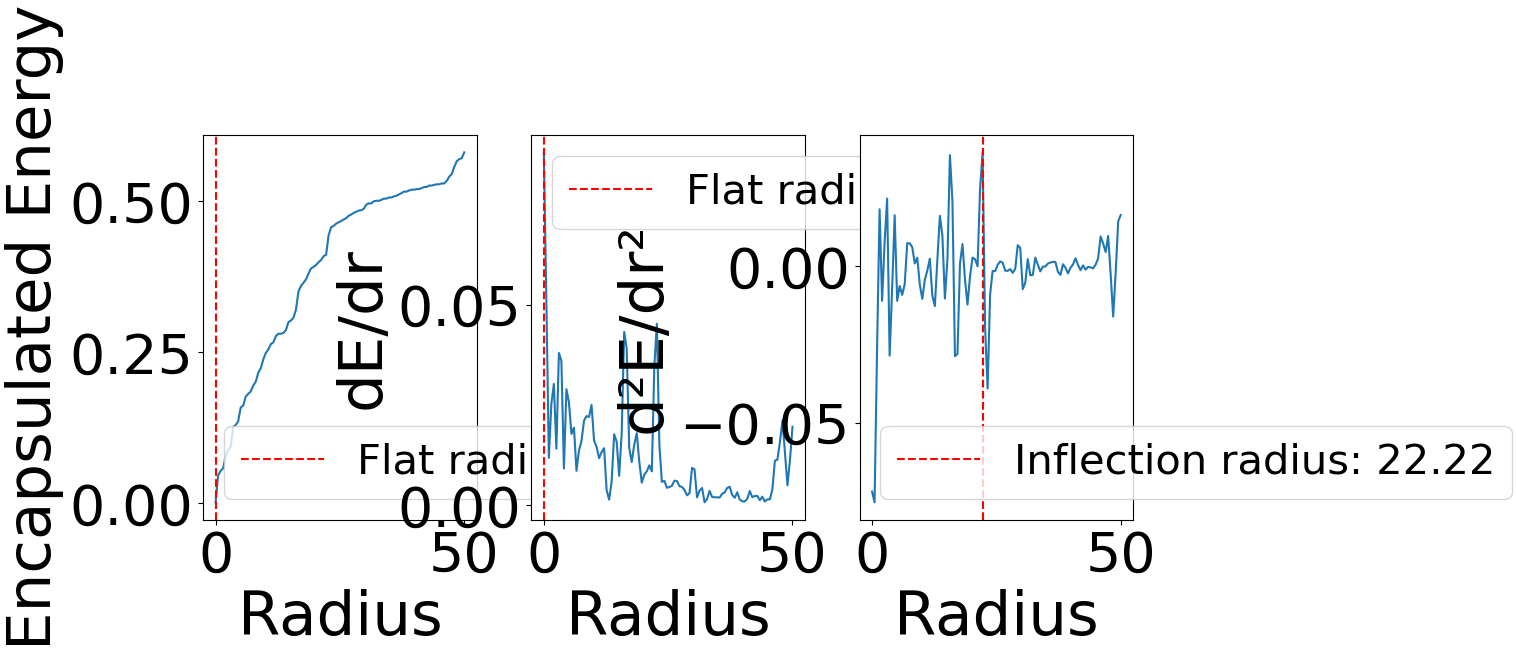

In [89]:
# extract blob energy by going to final points of the track, 
# calculating the energy around the final point radially, 
# and taking the derivative of that and choosing when the gradient does something funky

point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]
#print(point)
threshold = 0.5  # MeV


# hits belonging to the cluster
display(df)

def encapsulated_energy(df, point, radii):
    coords = df[['x', 'y', 'z']].to_numpy()
    dists  = cdist([point], coords).flatten()
    
    energies = [df[dists <= r]['energy'].sum() for r in radii]
    return np.array(energies)


radii    = np.linspace(0, 50, 100)
energies_1 = encapsulated_energy(df, point_1, radii)
energies_2 = encapsulated_energy(df, point_2, radii)

# derivative
dE_dr_1 = np.gradient(energies_1, radii)
dE_dr_2 = np.gradient(energies_2, radii)

# find where it flattens — below some threshold
threshold_1   = 0.01 * dE_dr_1.max()  # 1% of peak derivative
flat_idx_1    = np.argmax(dE_dr_1 < threshold)
flat_radius_1 = radii[flat_idx_1]

threshold_2   = 0.01 * dE_dr_2.max()  # 1% of peak derivative
flat_idx_2    = np.argmax(dE_dr_2 < threshold)
flat_radius_2 = radii[flat_idx_2]


# find second derivative
d2E_dr2_1     = np.gradient(dE_dr_1, radii)
inflect_idx_1  = np.argmax(d2E_dr2_1)
inflect_radius_1 = radii[inflect_idx_1]

# find second derivative
d2E_dr2_2     = np.gradient(dE_dr_2, radii)
inflect_idx_2  = np.argmax(d2E_dr2_2)
inflect_radius_2 = radii[inflect_idx_2]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(radii, energies_1)
axes[0].axvline(flat_radius_1, color='red', linestyle='--', label=f'Flat radius: {flat_radius_1:.2f}')
axes[0].set_xlabel('Radius')
axes[0].set_ylabel('Encapsulated Energy')
axes[0].legend()

axes[1].plot(radii, dE_dr_1)
axes[1].axvline(flat_radius_1, color='red', linestyle='--', label=f'Flat radius: {flat_radius_1:.2f}')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('dE/dr')
axes[1].legend()

axes[2].plot(radii, d2E_dr2_1)
axes[2].axvline(inflect_radius_1, color='red', linestyle='--', label=f'Inflection radius: {inflect_radius_1:.2f}')
axes[2].set_xlabel('Radius')
axes[2].set_ylabel('d²E/dr²')
axes[2].legend()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(radii, energies_2)
axes[0].axvline(flat_radius_2, color='red', linestyle='--', label=f'Flat radius: {flat_radius_2:.2f}')
axes[0].set_xlabel('Radius')
axes[0].set_ylabel('Encapsulated Energy')
axes[0].legend()

axes[1].plot(radii, dE_dr_2)
axes[1].axvline(flat_radius_2, color='red', linestyle='--', label=f'Flat radius: {flat_radius_2:.2f}')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('dE/dr')
axes[1].legend()

axes[2].plot(radii, d2E_dr2_2)
axes[2].axvline(inflect_radius_2, color='red', linestyle='--', label=f'Inflection radius: {inflect_radius_2:.2f}')
axes[2].set_xlabel('Radius')
axes[2].set_ylabel('d²E/dr²')
axes[2].legend()

plt.tight_layout()
plt.show()

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


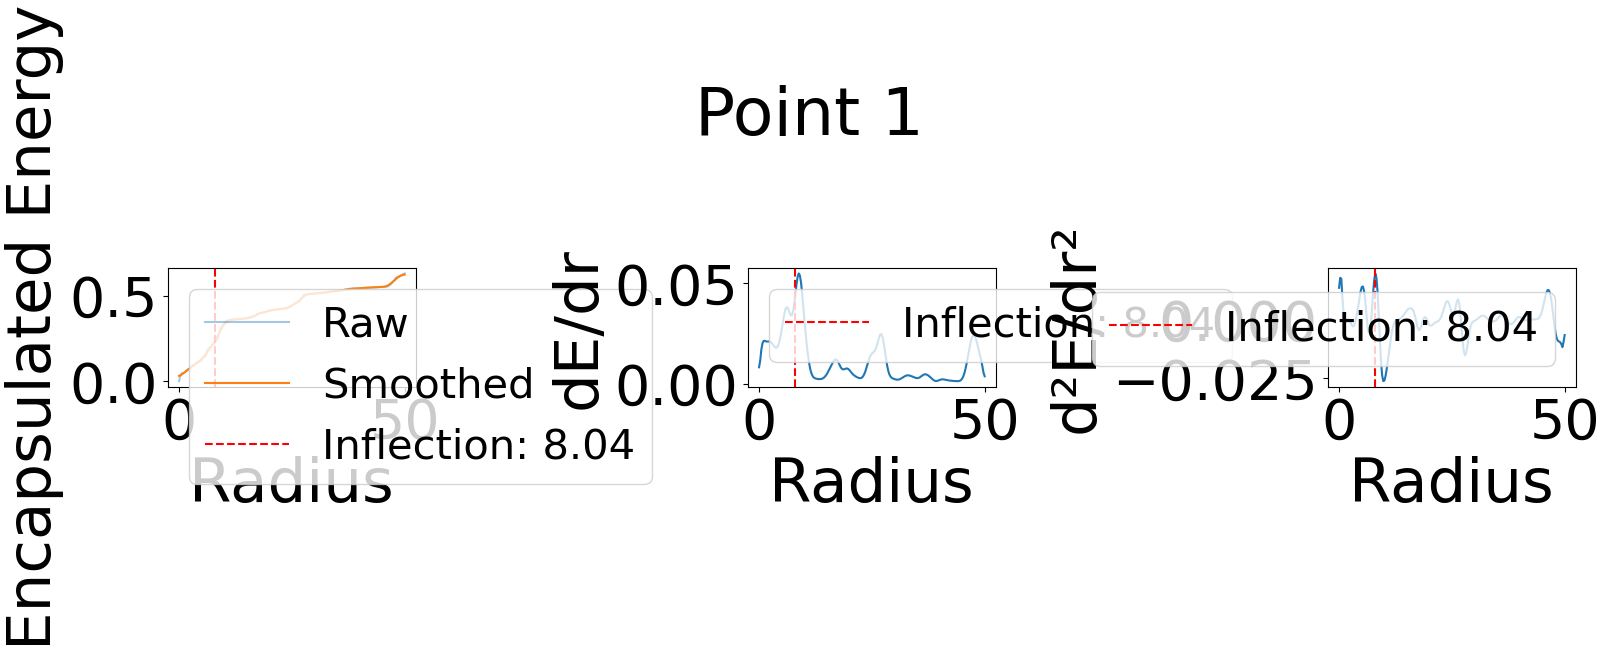

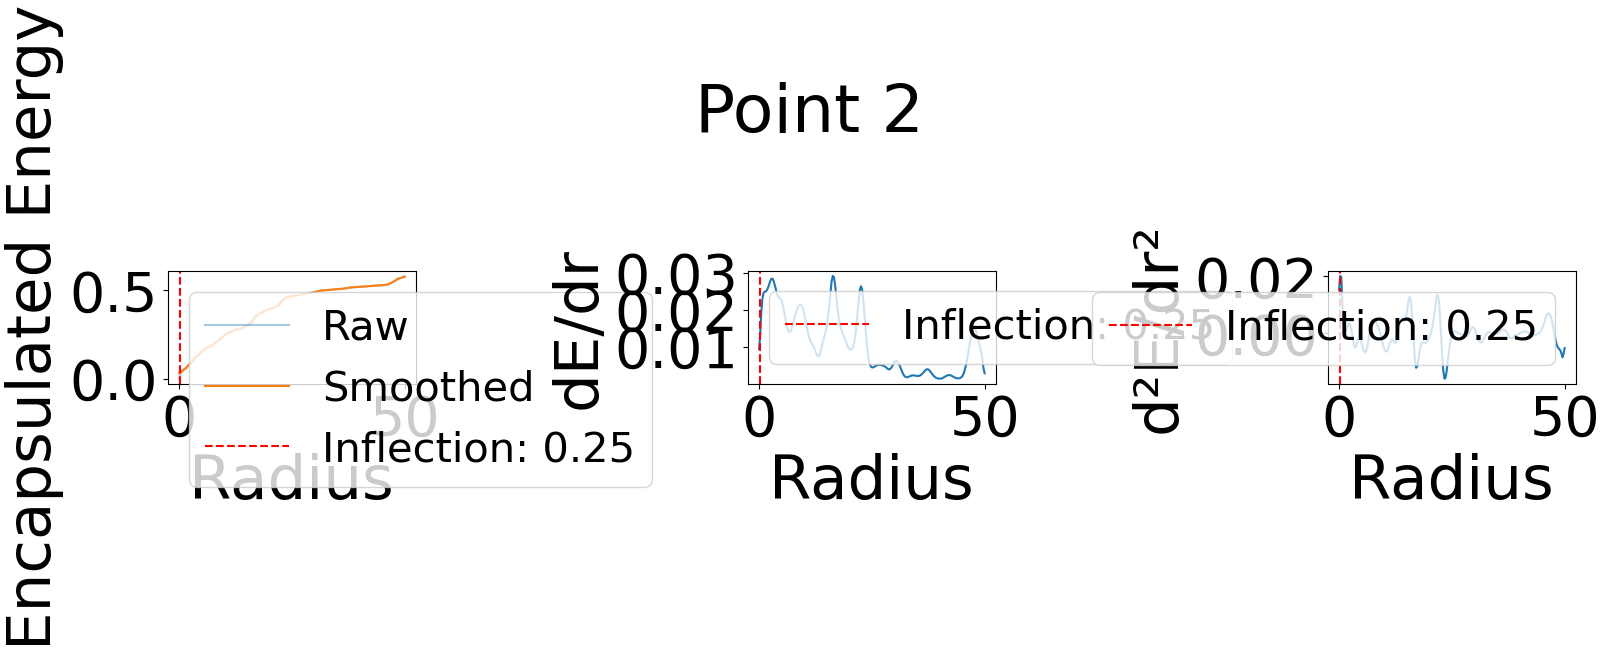

Point 1 blob energy: 0.2376
Point 2 blob energy: 0.0337


In [90]:
from scipy.ndimage import gaussian_filter1d

def encapsulated_energy(df, point, radii):
    coords = df[['x', 'y', 'z']].to_numpy()
    dists  = cdist([point], coords).flatten()
    return np.array([df[dists <= r]['energy'].sum() for r in radii])

def blob_energy_analysis(df, point, radii, sigma=5):
    energies        = encapsulated_energy(df, point, radii)
    energies_smooth = gaussian_filter1d(energies, sigma=sigma)
    dE_dr           = np.gradient(energies_smooth, radii)
    d2E_dr2         = np.gradient(dE_dr, radii)
    inflect_idx     = np.argmax(d2E_dr2)
    inflect_radius  = radii[inflect_idx]
    inflect_energy  = energies_smooth[inflect_idx]
    return energies, energies_smooth, dE_dr, d2E_dr2, inflect_radius, inflect_energy

def plot_blob_analysis(radii, energies, energies_smooth, dE_dr, d2E_dr2, inflect_radius, label=''):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(label)

    axes[0].plot(radii, energies,        alpha=0.4, label='Raw')
    axes[0].plot(radii, energies_smooth, label='Smoothed')
    axes[0].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[0].set_xlabel('Radius')
    axes[0].set_ylabel('Encapsulated Energy')
    axes[0].legend()

    axes[1].plot(radii, dE_dr)
    axes[1].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[1].set_xlabel('Radius')
    axes[1].set_ylabel('dE/dr')
    axes[1].legend()

    axes[2].plot(radii, d2E_dr2)
    axes[2].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[2].set_xlabel('Radius')
    axes[2].set_ylabel('d²E/dr²')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# points
point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

radii  = np.linspace(0, 50, 200)
sigma  = 3

results_1 = blob_energy_analysis(df, point_1, radii, sigma=sigma)
results_2 = blob_energy_analysis(df, point_2, radii, sigma=sigma)

energies_1, energies_smooth_1, dE_dr_1, d2E_dr2_1, inflect_radius_1, inflect_energy_1 = results_1
energies_2, energies_smooth_2, dE_dr_2, d2E_dr2_2, inflect_radius_2, inflect_energy_2 = results_2

plot_blob_analysis(radii, energies_1, energies_smooth_1, dE_dr_1, d2E_dr2_1, inflect_radius_1, label='Point 1')
plot_blob_analysis(radii, energies_2, energies_smooth_2, dE_dr_2, d2E_dr2_2, inflect_radius_2, label='Point 2')

print(f'Point 1 blob energy: {inflect_energy_1:.4f}')
print(f'Point 2 blob energy: {inflect_energy_2:.4f}')

In [91]:
def blob_radius(df, point, radii, threshold):
    coords   = df[['x', 'y', 'z']].to_numpy()
    dists    = cdist([point], coords).flatten()
    energies = np.array([df[dists <= r]['energy'].sum() for r in radii])
    idx      = np.argmax(energies >= threshold)
    return radii[idx]

point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

radii     = np.linspace(0, 50, 200)
#threshold = 0.5  # MeV

blob_e_1 = blob_energy_analysis(df, point_1, radii, threshold)
blob_e_2 = blob_energy_analysis(df, point_2, radii, threshold)


blob_r_1 = blob_radius(df, point_1, radii, threshold)
blob_r_2 = blob_radius(df, point_2, radii, threshold)

print(f'Point 1 blob energy: {blob_e_1:.4f}\nPoint 1 blob radius: {blob_r_1:.4f}\n')
print(f'Point 2 blob energy: {blob_e_2:.4f}\nPoint 2 blob radius: {blob_r_2:.4f}\n')

TypeError: unsupported format string passed to tuple.__format__

In [92]:
# how to quantify entanglement?
# naive start: take true length and maximum distance between hits as a ratio.

true_length = nubb0_pid.length.sum()
entanglement = (max_dist / true_length)
print(f'Entanglement: {entanglement*100:.2f}%')


Entanglement: 34.24%


In [93]:
display(df)
display(df_p)
print(list(df_p))

,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
1477,1,0.010303,0.342386,580.935547,0.003620,0.001505,ACTIVE,2,0,0
1478,1,-0.112376,0.595204,581.879211,0.007198,0.001088,ACTIVE,2,1,0
1479,1,-0.340987,0.626809,582.852112,0.010832,0.002784,ACTIVE,2,2,0
1480,1,-0.636849,0.715324,583.801941,0.014464,0.001074,ACTIVE,2,3,0
1481,1,-0.992695,0.710783,584.735352,0.018097,0.001033,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
3109,1,-7.039067,-169.158890,345.875854,2.400260,0.000257,ACTIVE,1,682,0
3110,1,-7.035063,-169.165176,345.857208,2.400737,0.002257,ACTIVE,1,683,0
3111,1,-7.032881,-169.166428,345.854767,2.400841,0.000292,ACTIVE,1,684,0
3112,1,-7.034186,-169.170532,345.847534,2.401103,0.001924,ACTIVE,1,685,0


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
69,1,3916,e-,0,2,-3.864816,-29.413263,591.506104,0.273158,-3.598248,...,0.033836,0.146046,0.120614,-0.0,-0.0,-0.0,0.035025,2.393882,eIoni,NoProcess
70,1,7705,e-,0,2,28.559145,-32.435555,585.617676,0.441592,28.888206,...,-0.071426,0.099203,-0.059719,0.0,0.0,0.0,0.017801,0.728963,eIoni,NoProcess
71,1,12071,e-,0,2,34.305172,-60.401295,581.797058,0.734256,34.251755,...,-0.037181,-0.116086,-0.021722,0.0,-0.0,0.0,0.014786,0.513130,eIoni,NoProcess
72,1,13293,e-,0,2,33.030727,-54.763699,588.663635,0.778293,32.981773,...,-0.119052,0.051345,0.013397,-0.0,-0.0,-0.0,0.016362,0.638501,eIoni,NoProcess
73,1,15039,gamma,0,2,35.959293,-60.028492,590.301514,0.862421,37.647312,...,0.002402,-0.019521,0.000401,0.0,-0.0,0.0,0.019673,13.823136,eBrem,phot
74,1,15083,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647301,...,-0.000889,-0.006112,-0.002953,0.0,0.0,-0.0,0.000046,0.000098,phot,NoProcess
75,1,15082,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647308,...,-0.002713,0.000705,0.006132,-0.0,0.0,0.0,0.000044,0.000013,phot,NoProcess
76,1,15081,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647282,...,-0.003235,-0.002717,-0.001779,-0.0,-0.0,0.0,0.000021,0.000045,phot,NoProcess
77,1,15080,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647472,...,0.004363,0.002150,0.007125,-0.0,-0.0,0.0,0.000073,0.000667,phot,NoProcess
78,1,15079,e-,0,15039,37.647312,-73.745277,590.583313,0.908530,37.647182,...,-0.004483,-0.012144,-0.002943,-0.0,-0.0,-0.0,0.000172,0.001154,phot,NoProcess


['event_id', 'particle_id', 'particle_name', 'primary', 'mother_id', 'initial_x', 'initial_y', 'initial_z', 'initial_t', 'final_x', 'final_y', 'final_z', 'final_t', 'initial_volume', 'final_volume', 'initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z', 'final_momentum_x', 'final_momentum_y', 'final_momentum_z', 'kin_energy', 'length', 'creator_proc', 'final_proc']


In [94]:
# quantify full energy
print(df.energy.sum())
print(df_p[df_p.particle_id.isin(df.particle_id.values)].kin_energy.sum())

2.4381576
2.9419737


[0.9846165  0.9998987  0.9987712  ... 0.00350501 0.00841792 0.00220954]
0.96504295
Average energy deposited
1.54 keV
Median energy deposited
1.15 keV
Maximum energy by a hit
13.66 keV
Total energy (MeV)
2.4381576


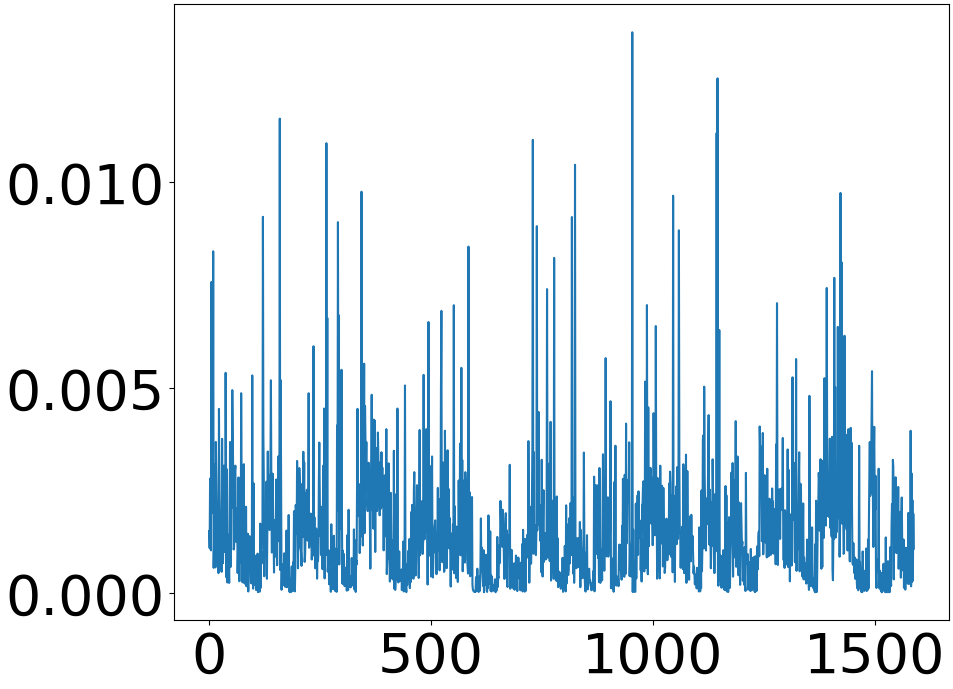

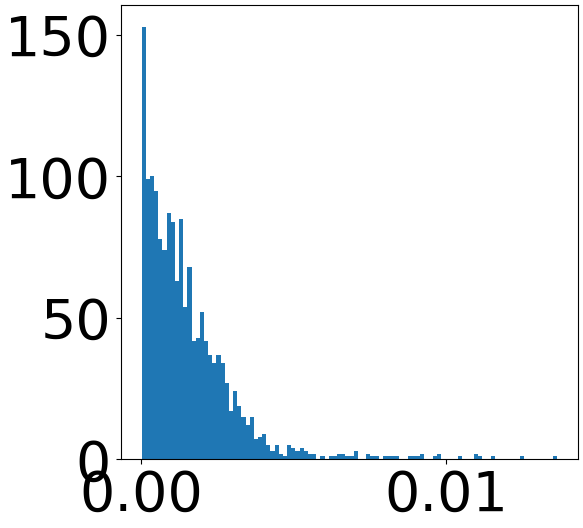

In [95]:
coords = df[['x', 'y', 'z']]
dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
print(dists)
print(np.median(dists))
print('Average energy deposited')
print(f"{np.average(df['energy'])*1000:.2f} keV")
print('Median energy deposited')
print(f"{np.median(df['energy'])*1000:.2f} keV")
print("Maximum energy by a hit")
print(f"{np.max(df['energy'].values)*1000:.2f} keV")
print(f"Total energy (MeV)")
print(df['energy'].sum())
plt.figure(figsize=(10,8))
plt.plot(np.linspace(0, len(df['energy'].values -1), len(df['energy'].values)), df['energy'].values)
plt.show()

plt.hist(df['energy'].values, bins = 100)
plt.show()

In [79]:
!pwd

/gluster/data/next/notebooks/topology_MC_study


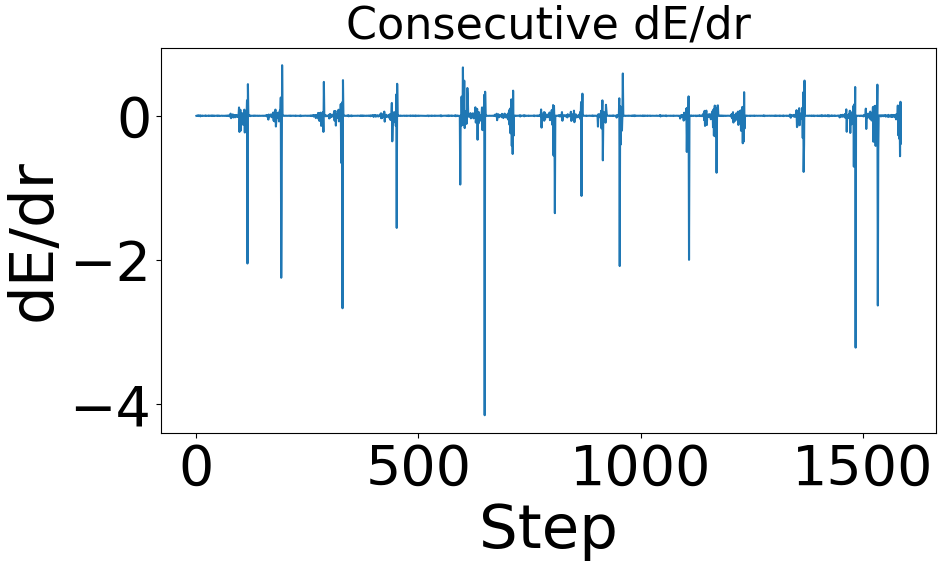

Median dE/dr: -7.47435333323665e-05
1148.4321355819702


In [100]:
# hit energy density is simple
def dE_dr_consecutive(df):
    
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    dE    = np.diff(energies)
    
    return dE / dists

def dE_dr_simple(df):
    # assuming dr is always 1
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    # energy per hit, simple
    return energies*1000 


de_dr = dE_dr_consecutive(df)
plt.figure(figsize=(10, 5))
plt.plot(de_dr)
plt.xlabel('Step')
plt.ylabel('dE/dr')
plt.title('Consecutive dE/dr')
plt.show()

print(f'Median dE/dr: {np.median(de_dr)}')
print(np.median(dE_dr_simple(df))*1000)

In [104]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, cdist

from pathlib import Path



def load_h5_files(folder, key, slices = None):
    files = list(Path(folder).glob("*.h5"))[:slices]
    return pd.concat([pd.read_hdf(f, key) for f in files], ignore_index = True)


# hit energy density is simple
def dE_dr_consecutive(df):
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    dE    = np.diff(energies)
    
    return dE / dists


def blob_radius(df, point, radii, threshold):
    coords   = df[['x', 'y', 'z']].to_numpy()
    dists    = cdist([point], coords).flatten()
    energies = np.array([df[dists <= r]['energy'].sum() for r in radii])
    idx      = np.argmax(energies >= threshold)
    return radii[idx]


def tag_hits_in_event(event_hits   : pd.DataFrame
                     , *
                     , min_samples : int
                     , scale_xy    : float
                     , scale_z     : float
                     ) -> pd.DataFrame:
    """
    Applies DBSCAN clustering to a DataFrame containing hits from a single event.
    Hits coordinates are scaled to account for the anisotropy of the detector geometry.
    A 'cluster' column is added to the group with the resulting labels.

    Parameters
    ----------
    event_hits  : pd.DataFrame
        DataFrame with hits from a single event. Must contain 'X', 'Y', 'Z' columns.
    min_samples : int
        Minimum number of samples required to form a dense region (cluster).
        This includes the point itself.
    scale_xy    : float
        Scaling factor to apply to the XY coordinates before clustering.
    scale_z     : float
        Scaling factor to apply to the Z coordinate before clustering.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with a 'cluster' column added.
    """
    coords = event_hits[['x', 'y', 'z']].to_numpy()
    # A proper scaling leads to hits being separeted 
    # by a distance of 1 in the DBSCAN metric space
    coords[:, :2] /= scale_xy
    coords[:, 2]  /= scale_z

    # eps parameter is fixed to a value a bit higher of √3
    # to retain diagonal neighbours in the same cluster
    labels = DBSCAN(eps=1.8, min_samples=min_samples).fit_predict(coords)
    event_hits['cluster'] = labels

    return event_hits


def cluster_tagger(df_hits      : pd.DataFrame
                  , *
                  , min_samples : int
                  , scale_xy    : float
                  , scale_z     : float
                  ) -> pd.DataFrame:
    """
    This function groups the input DataFrame by 'event' and applies the
    `tag_hits_in_event` function to each event's group of hits.

    Parameters
    ----------
    df_hits : pd.DataFrame
        DataFrame with hit information. Must contain 'X', 'Y', 'Z', and 'event'.
    min_samples, scale_xy, scale_z : 
        See `tag_hits_in_event`
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'cluster' column indicating the
        cluster label for each hit (-1 for noise).
    """
    if df_hits.empty:
        return df_hits.assign(cluster=pd.Series(dtype=int))

    df_clustered = df_hits.groupby('event_id', as_index=False, group_keys=False) \
                          .apply( tag_hits_in_event
                                , min_samples = min_samples
                                , scale_xy    = scale_xy
                                , scale_z     = scale_z )
    
    return df_clustered.set_index(df_hits.index)
    

def extract_topological_info(hits_df, pinfo_df, threshold = 0.4):
    '''
    Extract entanglement, preferred blob radius 
    radial_threshold in MeV
    '''
    true_lengths   = [] # what the MC particle info gives, end to end
    max_extents    = [] # what are the two furthest apart hits in the track
    entanglements  = [] # max_extents / true_lengths, simply
    blob_1_size    = []
    blob_2_size    = []
    de_drs         = []
    de_drs_simple_med  = []
    de_drs_simple_ave = []
    
    # cluster tracks, extract the largest (assuming this is a 0nubb track)
    tagged_hits = cluster_tagger(hits_df, min_samples = 5, scale_xy = 2, scale_z = 2)
    
    for evt, df in tqdm(tagged_hits.groupby('event_id'), total=tagged_hits['event_id'].nunique()):
        # check if event has one track larger than 100. If so, include
        if (df.cluster.value_counts() > 100).sum() == 1:
            dominant_cluster = df['cluster'].value_counts()[df['cluster'].value_counts() > 100].index[0]
            df = df[df['cluster'] == dominant_cluster]
        else:
            continue
            
        ############################################################
        # max extent of track (furthest two hits apart)
        ############################################################

        coords = df[['x', 'y', 'z']].to_numpy()
        dists  = cdist(coords, coords)
        idx    = np.unravel_index(dists.argmax(), dists.shape)

        #pos_a    = df[['x', 'y', 'z']].iloc[idx[0]]
        #pos_b    = df[['x', 'y', 'z']].iloc[idx[1]]
        max_dist = dists[idx]
        max_extents.append(max_dist)
        
        ############################################################
        # true length of track
        ############################################################
        
        # create mask for specific event
        mask = (pinfo_df.event_id == df.event_id.unique()[0]) & (pinfo_df.creator_proc == 'none')
        nubb0_pid = pinfo_df[mask]
        
        # if it has only two elements, you've done it correctly. If not, something odd has happened.
        # this is because 0nubb is not given a process in MC particle info (lmao)
        if len(nubb0_pid) != 2:
            print(f"More than 2 events explicitly from 0nubb! You've messed up!\ndf: {nubb0_pid}")
            continue
        
        true_length = nubb0_pid.length.sum()
        true_lengths.append(nubb0_pid.length.sum())
        
        ############################################################
        # entanglement
        ############################################################
        entanglement = (max_dist / true_length)
        entanglements.append(entanglement)
        
        ############################################################
        # blob size
        ############################################################
        point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
        point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

        radii     = np.linspace(0, 50, 200)
        
        blob_r_1 = blob_radius(df, point_1, radii, threshold)
        blob_r_2 = blob_radius(df, point_2, radii, threshold)
        
        blob_1_size.append(blob_r_1)
        blob_2_size.append(blob_r_2)
    
        ############################################################
        # dE/dr
        ############################################################
        de_dr = dE_dr_consecutive(df)
        de_drs.append(np.median(de_dr))
        
        de_dr = dE_dr_simple(df)
        de_drs_simple_med.append(np.median(de_dr))    
        de_drs_simple_ave.append(np.average(de_dr))    
    return dict(
                max_extent   = max_extents,
                true_length  = true_lengths,
                entanglement = entanglements,
                blob_1_size  = blob_1_size,
                blob_2_size  = blob_2_size,
                de_dr        = de_drs,
                de_dr_simp_med   = de_drs_simple_med,
                de_dr_simp_ave = de_drs_simple_ave)

In [105]:
path_5bar = '/gluster/data/next/files/NEXUS_John/0vbb/4bar/'

hits_5bar  = load_h5_files(path_5bar, 'MC/hits', 5)
pinfo_5bar = load_h5_files(path_5bar, 'MC/particles', 5)
display(hits_5bar)
display(pinfo_5bar)


,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,0,0.242759,0.944014,579.782104,0.003411,0.000434,ACTIVE,2,0
1,0,0.445227,1.897144,579.557434,0.006827,0.002103,ACTIVE,2,1
2,0,0.665996,2.841517,579.314758,0.010242,0.001522,ACTIVE,2,2
3,0,0.874691,3.790327,579.079834,0.013656,0.002545,ACTIVE,2,3
4,0,1.064330,4.745380,578.852783,0.017071,0.001455,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
7838565,4999,123.592705,10.686277,435.896667,2.619385,0.000098,ACTIVE,1,758
7838566,4999,123.596489,10.687006,435.890991,2.619583,0.001618,ACTIVE,1,759
7838567,4999,123.596260,10.688207,435.891846,2.619642,0.000015,ACTIVE,1,760
7838568,4999,123.595810,10.690542,435.893463,2.619757,0.001285,ACTIVE,1,761


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,0,13687,e-,0,2,59.034023,201.040787,668.979126,0.985165,59.238186,...,-0.123317,0.098230,0.031521,0.0,0.0,-0.0,0.024697,1.173147,eIoni,NoProcess
1,0,15667,e-,0,2,49.820789,216.891861,650.064819,1.084065,50.478207,...,0.021997,0.145530,0.184855,-0.0,0.0,-0.0,0.051988,4.827109,eIoni,NoProcess
2,0,20296,e-,0,2,60.965145,256.797241,611.460999,1.302842,67.142838,...,0.151952,-0.005464,-0.354362,0.0,0.0,0.0,0.129166,22.028923,eIoni,NoProcess
3,0,24324,e-,0,2,62.440292,261.262329,607.643616,1.325448,61.294357,...,-0.095213,-0.108492,-0.144775,0.0,-0.0,-0.0,0.039379,2.619502,eIoni,NoProcess
4,0,27633,e-,0,2,80.098984,282.717072,604.896301,1.525872,80.018227,...,-0.096487,0.180604,0.021616,0.0,0.0,-0.0,0.039923,2.956932,eIoni,NoProcess
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222654,4999,43607,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.839783,...,-0.015963,-0.013234,-0.007333,-0.0,-0.0,-0.0,0.000473,0.003339,phot,NoProcess
222655,4999,43606,e-,0,43593,57.840431,63.038265,448.643768,1.356758,57.870083,...,-0.057298,0.072363,0.060479,0.0,-0.0,0.0,0.011779,0.487257,phot,NoProcess
222656,4999,54751,e-,0,1,124.659485,14.253165,453.109955,2.148500,124.667755,...,0.047024,0.020670,-0.100803,-0.0,-0.0,0.0,0.012374,0.115835,eIoni,NoProcess
222657,4999,60499,e-,0,1,119.512756,6.900838,439.812958,2.485482,119.516144,...,-0.042584,0.118401,0.037350,0.0,-0.0,-0.0,0.016587,0.696750,eIoni,NoProcess


In [106]:
dict_5bar = extract_topological_info(hits_5bar, pinfo_5bar)

  1%|          | 36/5000 [00:03<06:36, 12.50it/s]/tmp/ipykernel_1499239/305334650.py:28: RuntimeWarning: divide by zero encountered in divide
  return dE / dists
 67%|██████▋   | 3352/5000 [05:27<02:15, 12.14it/s]/tmp/ipykernel_1499239/305334650.py:28: RuntimeWarning: invalid value encountered in divide
  return dE / dists
100%|██████████| 5000/5000 [08:10<00:00, 10.20it/s]


In [115]:
dict_5bar.keys()

dict_keys(['max_extent', 'true_length', 'entanglement', 'blob_1_size', 'blob_2_size', 'de_dr', 'de_dr_simp_med', 'de_dr_simp_ave'])

In [107]:
# 10 bar
path_13bar = '/gluster/data/next/files/NEXUS_John/0vbb/10bar/'

hits_13bar  = load_h5_files(path_13bar, 'MC/hits', 5)
pinfo_13bar = load_h5_files(path_13bar, 'MC/particles', 5)

In [108]:
dict_13bar = extract_topological_info(hits_13bar, pinfo_13bar)

  0%|          | 23/5000 [00:02<08:06, 10.23it/s]/tmp/ipykernel_1499239/305334650.py:28: RuntimeWarning: divide by zero encountered in divide
  return dE / dists
 66%|██████▋   | 3318/5000 [04:57<02:45, 10.18it/s]/tmp/ipykernel_1499239/305334650.py:28: RuntimeWarning: invalid value encountered in divide
  return dE / dists
100%|██████████| 5000/5000 [07:27<00:00, 11.17it/s]


In [109]:
def print_histos(dct_5b, dct_13b, key, histo_label, bins = 50):
    '''
    print the histograms for 5 bar and 13 bar based on key
    '''
    # catch NaNs
    arr_5b  = np.array(dct_5b[key],  dtype=float)
    arr_13b = np.array(dct_13b[key], dtype=float)
    
    arr_5b  = arr_5b[np.isfinite(arr_5b)]
    arr_13b = arr_13b[np.isfinite(arr_13b)]
    
    combined = np.concatenate([arr_5b, arr_13b])
    range_   = (combined.min(), combined.max())
    
    plt.hist(dct_5b[key],  alpha=0.5, label='5 bar',  bins=bins, range=range_)
    plt.hist(dct_13b[key], alpha=0.5, label='13 bar', bins=bins, range=range_)
    plt.xlabel(histo_label)
    plt.ylabel('Counts')
    plt.legend()
    plt.show()

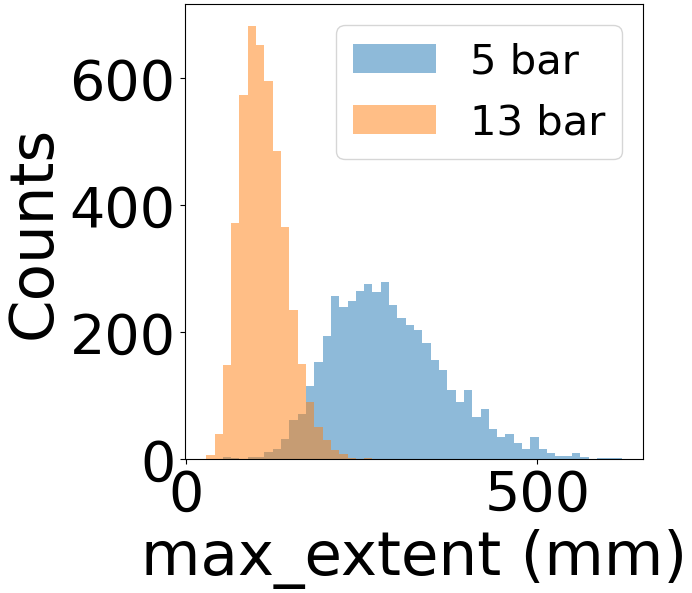

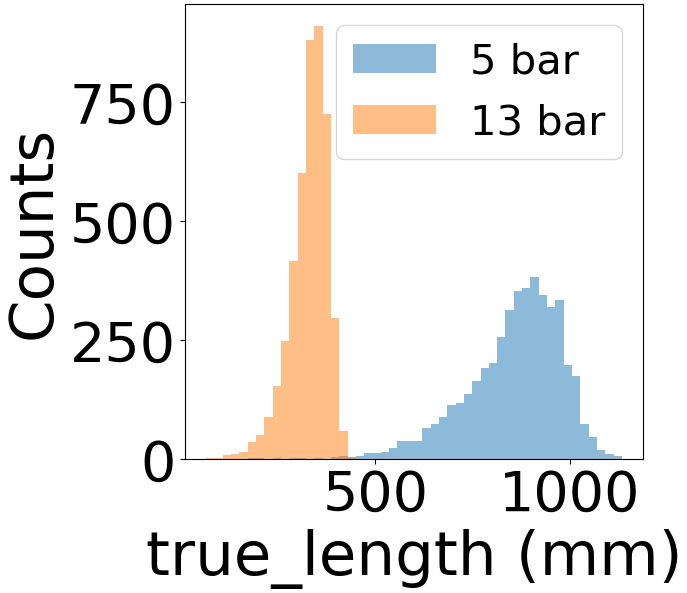

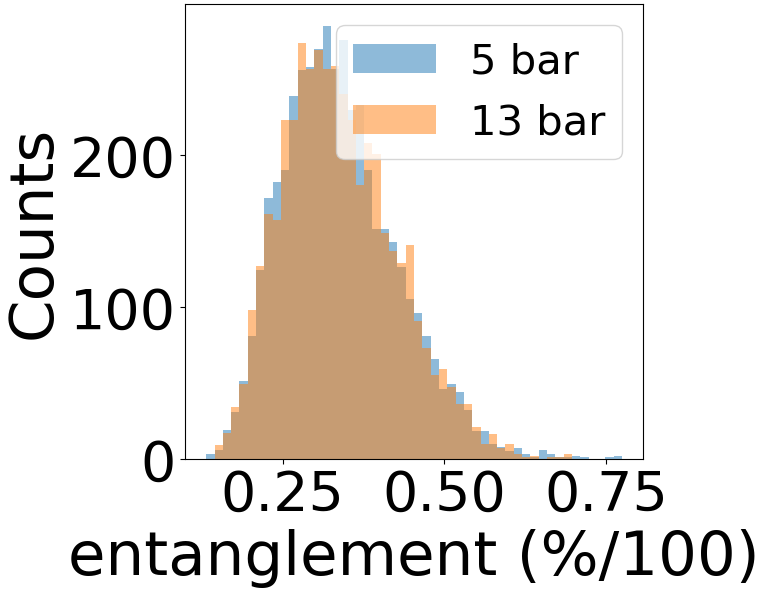

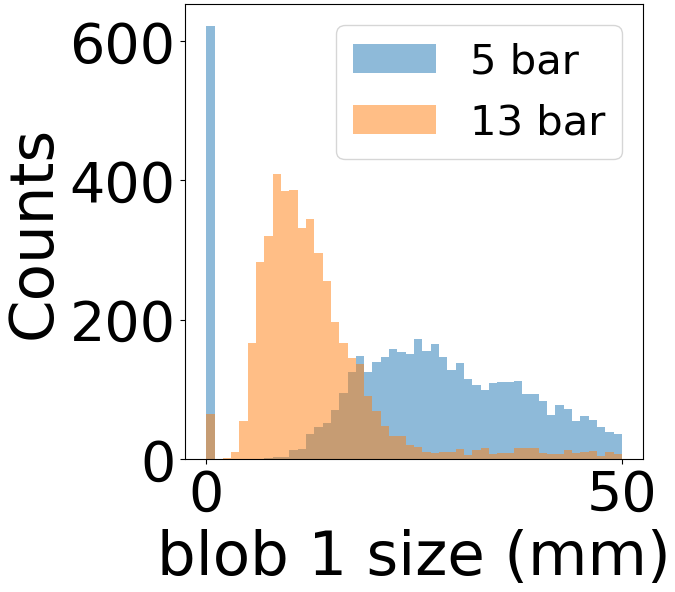

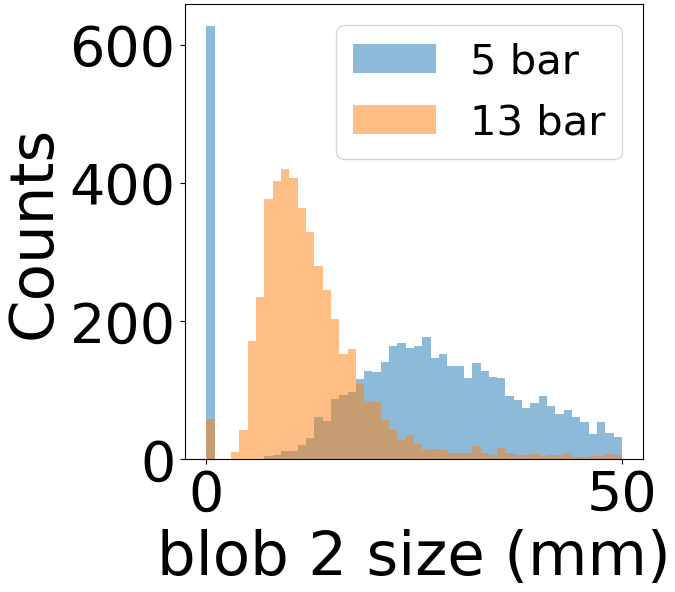

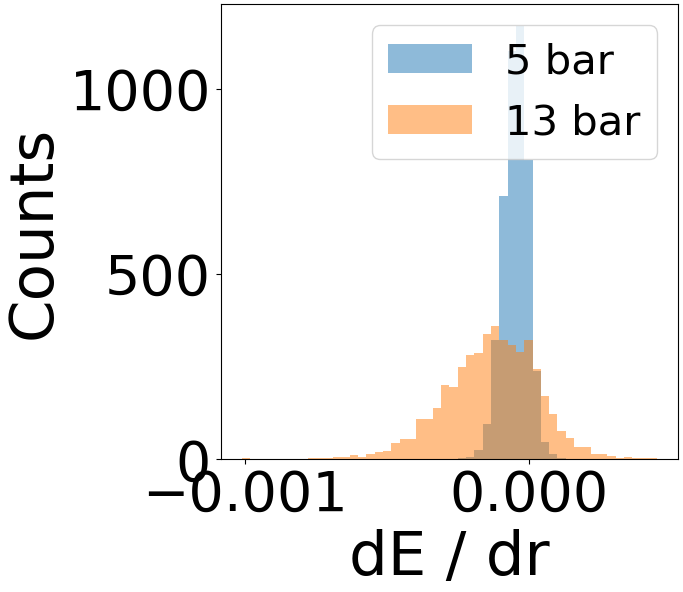

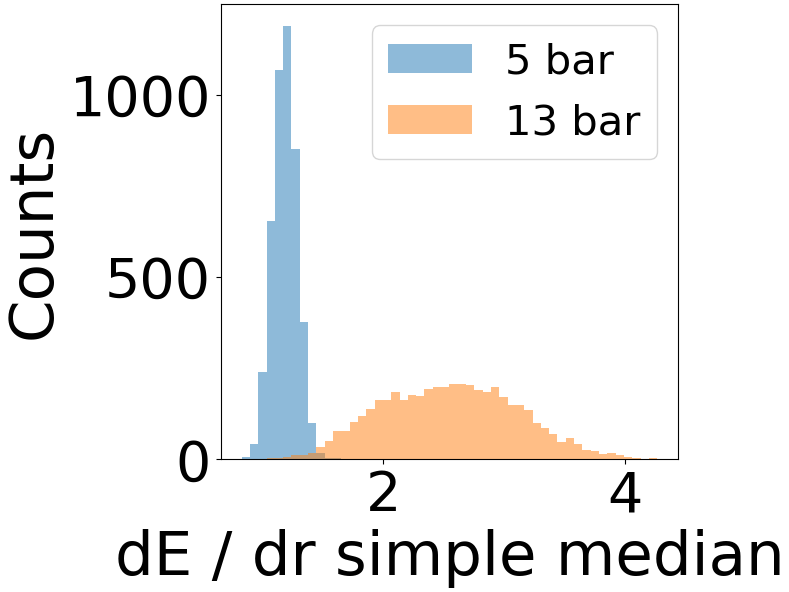

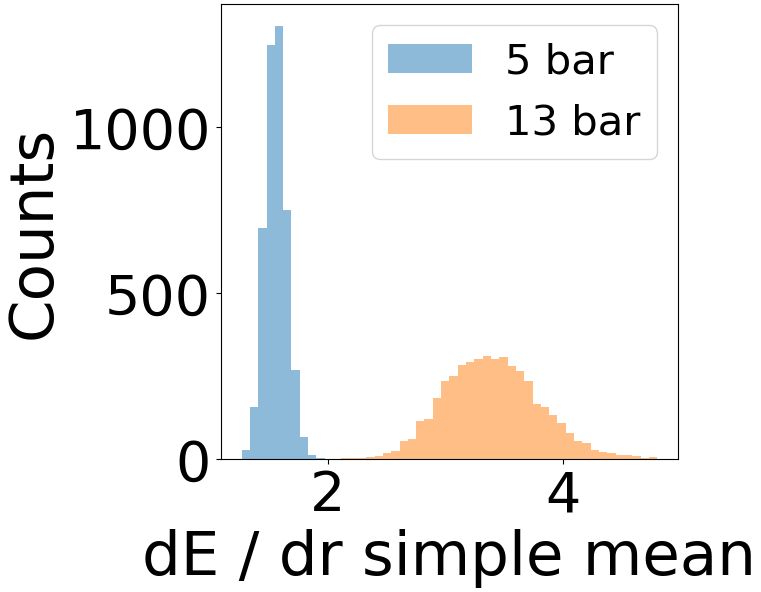

In [116]:
x_labels_histo = ['max_extent (mm)', 'true_length (mm)', 'entanglement (%/100)', 'blob 1 size (mm)', 'blob 2 size (mm)', 'dE / dr', 'dE / dr simple median', 'dE / dr simple mean']

for key, label in zip(dict_13bar.keys(), x_labels_histo):
    print_histos(dict_5bar, dict_13bar, key, str(label))


In [118]:


def print_histos_adv(dct_5b, dct_13b, key, histo_label, bins=50, abs=False):
    if abs:
        arr_5b  = np.abs(np.array(dct_5b[key],  dtype=float))
        arr_13b = np.abs(np.array(dct_13b[key], dtype=float))
    else:
        arr_5b  = np.array(dct_5b[key],  dtype=float)
        arr_13b = np.array(dct_13b[key], dtype=float)

    arr_5b  = arr_5b[np.isfinite(arr_5b)]
    arr_13b = arr_13b[np.isfinite(arr_13b)]

    if key in ('blob_1_size', 'blob_2_size'):
        arr_5b  = arr_5b[arr_5b   >= 1]
        arr_13b = arr_13b[arr_13b >= 1]

    if key in ('de_dr'):
        
        arr_5b = arr_5b
        arr_13b = arr_13b
    combined = np.concatenate([arr_5b, arr_13b])
    range_   = (combined.min(), combined.max())

    plt.hist(arr_5b,  alpha=0.5, label='4 bar',  bins=bins, range=range_)
    plt.hist(arr_13b, alpha=0.5, label='10 bar', bins=bins, range=range_)
    plt.xlabel(histo_label)
    plt.ylabel('Counts')
    plt.legend()
    plt.show()
    print(f'Median for 10 bar: {np.median(arr_13b)}')
    print(f'Mean for 10 bar: {np.average(arr_13b)}')
    print(f'Median for 4 bar: {np.median(arr_5b)}')
    print(f'Mean for 4 bar: {np.average(arr_5b)}')
    


max_extent


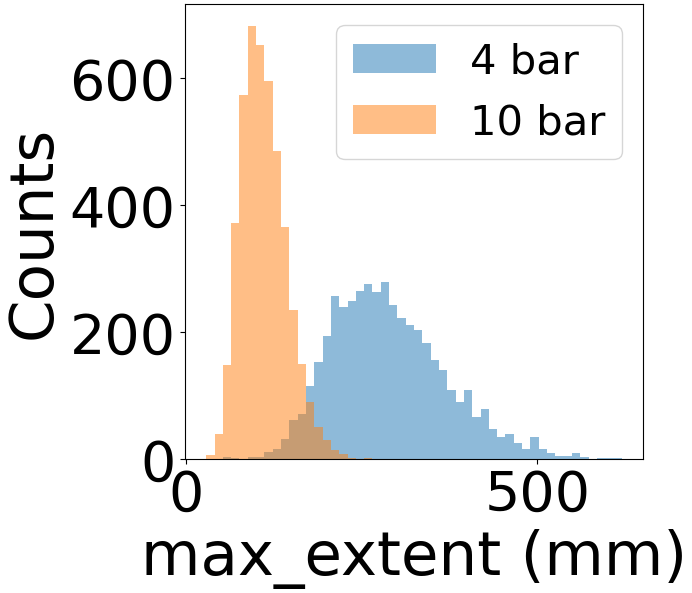

Median for 10 bar: 107.56304468050698
Mean for 10 bar: 110.86751121370276
Median for 4 bar: 280.0638163755697
Mean for 4 bar: 288.77378993155514
true_length


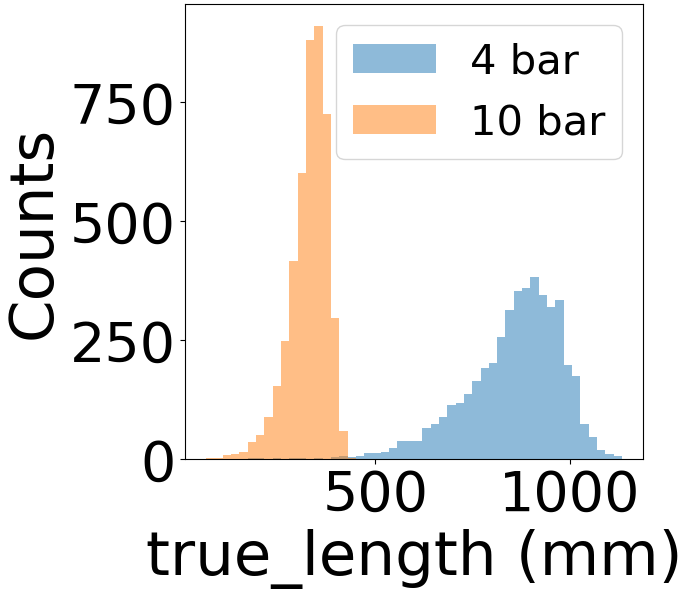

Median for 10 bar: 337.32208251953125
Mean for 10 bar: 329.2955514154914
Median for 4 bar: 877.3142700195312
Mean for 4 bar: 857.2839690757903
entanglement


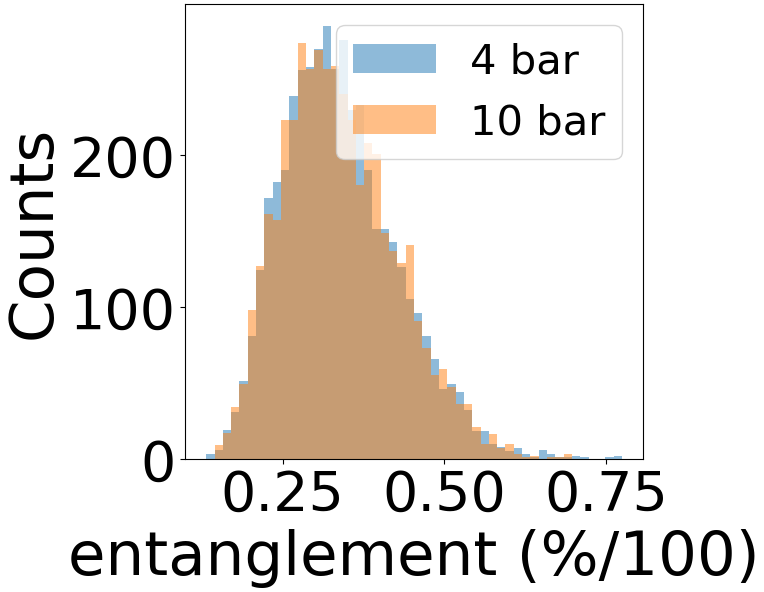

Median for 10 bar: 0.32922413098577064
Mean for 10 bar: 0.3385519370787326
Median for 4 bar: 0.32874991894102756
Mean for 4 bar: 0.33892104472086493
blob_1_size


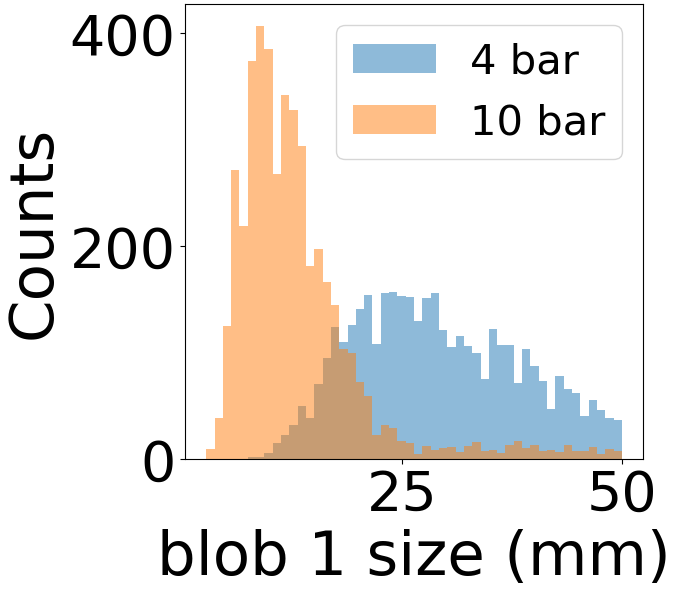

Median for 10 bar: 11.557788944723617
Mean for 10 bar: 13.197733984893988
Median for 4 bar: 27.889447236180903
Mean for 4 bar: 29.078799833353045
blob_2_size


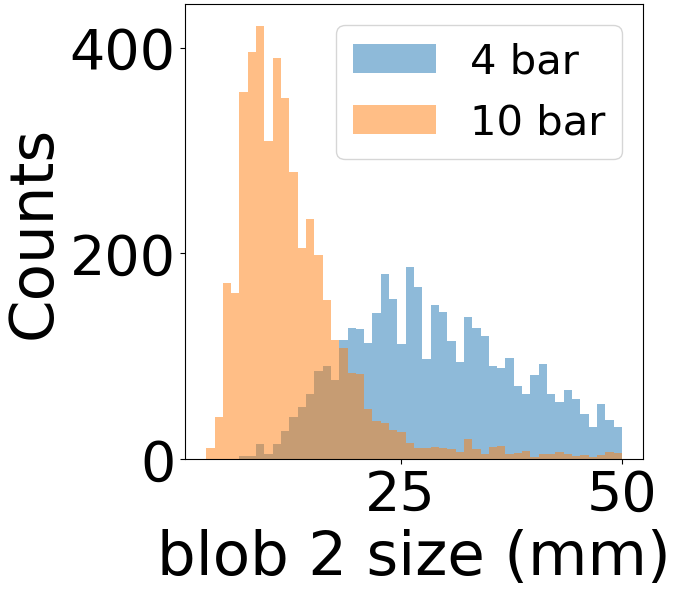

Median for 10 bar: 11.306532663316581
Mean for 10 bar: 12.893140182427011
Median for 4 bar: 27.889447236180903
Mean for 4 bar: 28.89241235642728
de_dr


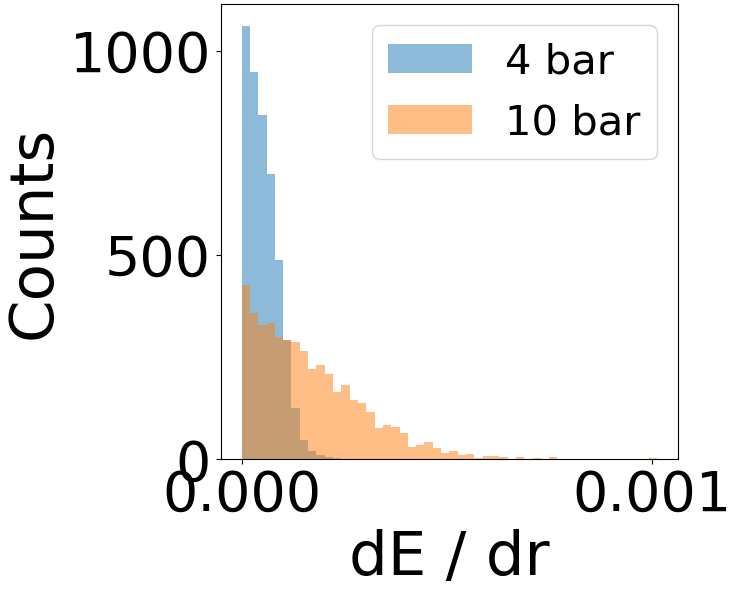

Median for 10 bar: 0.00013618491357192397
Mean for 10 bar: 0.00016282057435274203
Median for 4 bar: 4.667812027037144e-05
Mean for 4 bar: 5.203976034389202e-05
de_dr_simp_med


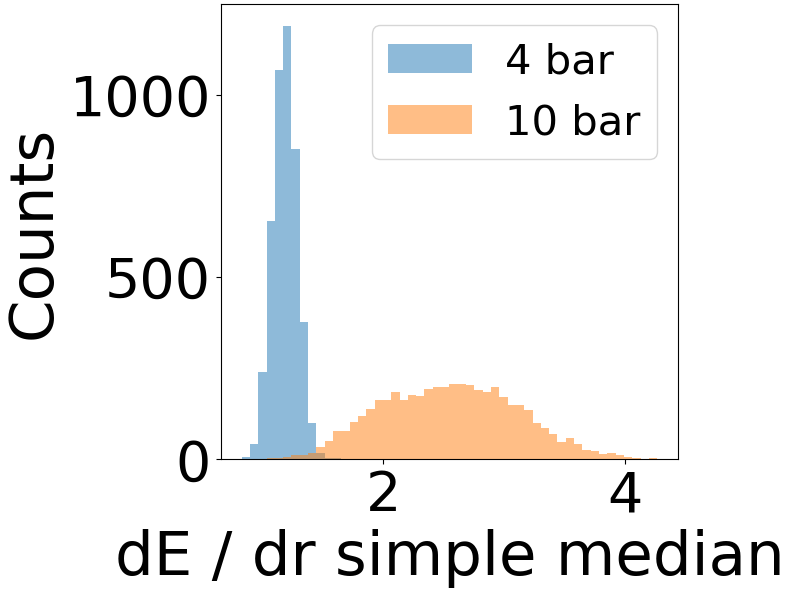

Median for 10 bar: 2.553916573524475
Mean for 10 bar: 2.5527277483800064
Median for 4 bar: 1.1843222379684448
Mean for 4 bar: 1.186395950046333
de_dr_simp_ave


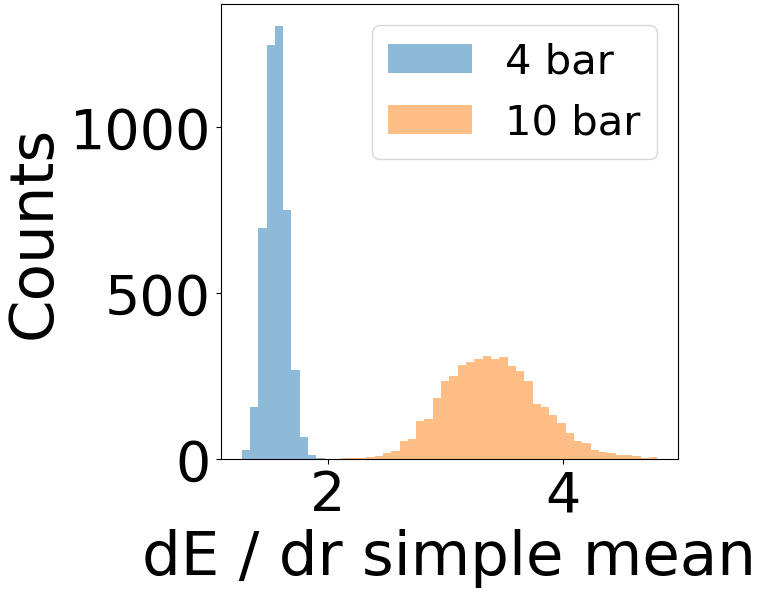

Median for 10 bar: 3.380784034729004
Mean for 10 bar: 3.3972931960237043
Median for 4 bar: 1.5555888414382935
Mean for 4 bar: 1.5584285286088653


In [119]:
x_labels_histo = ['max_extent (mm)', 'true_length (mm)', 'entanglement (%/100)', 'blob 1 size (mm)', 'blob 2 size (mm)', 'dE / dr', 'dE / dr simple median', 'dE / dr simple mean']

for key, label in zip(dict_13bar.keys(), x_labels_histo):
    print(key)
    if key in ('de_dr'):
        print_histos_adv(dict_5bar, dict_13bar, key, str(label), abs = True)
    else:
        print_histos_adv(dict_5bar, dict_13bar, key, str(label))


In [114]:
import pickle

with open('dict_4bar.pkl', 'wb') as f:
    pickle.dump(dict_5bar, f)

with open('dict_10bar.pkl', 'wb') as f:
    pickle.dump(dict_13bar, f)